<a href="https://colab.research.google.com/github/LeviSalazarJmz/MachineLearning/blob/main/PU4_Segmentacion_Pacientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Vista Previa del Dataset Original ===
Dimensiones iniciales: 6000 filas, 16 columnas

   age  gender  chest_pain_type  blood_pressure  cholesterol  max_heart_rate  \
0   24     1.0                4             250          139             212   
1   29     0.0                4             132          187             147   
2   46     0.0                3             271          185             193   
3   73     NaN                2             102          200             125   
4   49     1.0                3              91          163             192   

   exercise_angina  plasma_glucose  skin_thickness  insulin        bmi  \
0                0           108.0            33.0    109.0  37.999303   
1                0           202.0            42.0      NaN  25.588346   
2                0           149.0            43.0    102.0  37.892029   
3                0           105.0            77.0    165.0  18.660241   
4                0           162.0            31.0    170.0

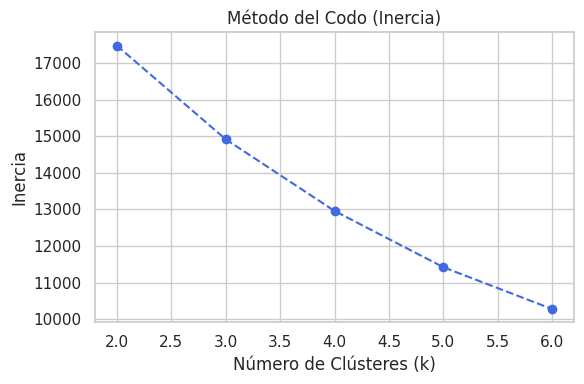


=== Tabla Comparativa de Desempeño por k ===
 Cantidad de Clústeres (k)      Inercia  Silhouette Score
                         2 17479.609180          0.192736
                         3 14919.379654          0.187652
                         4 12960.434968          0.199815
                         5 11422.738876          0.216836
                         6 10278.902296          0.212290

-> El número óptimo seleccionado basado en la métrica Silhouette es k = 5


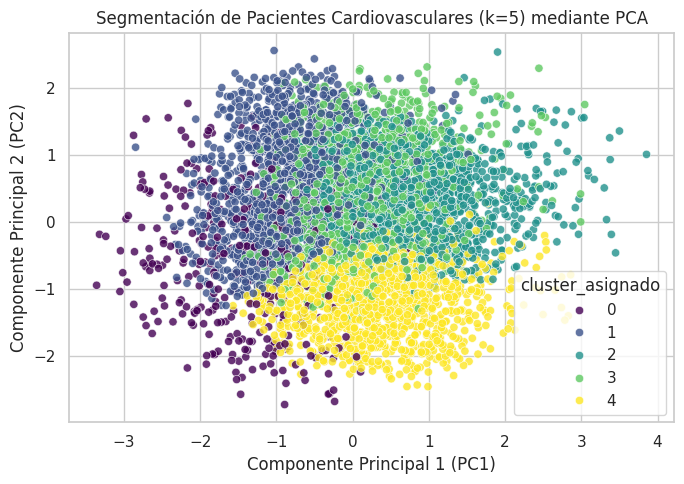


=== Promedio de Variables Clínicas por Clúster ===
                  blood_pressure  cholesterol  plasma_glucose  max_heart_rate
cluster_asignado                                                             
0                      21.504155   208.955679      156.534626      147.434903
1                     139.410906   262.277266      160.695853      111.031490
2                     146.390499   207.157005      209.687601      182.388889
3                     141.896832   161.610885      165.774167      107.480097
4                     141.921912   206.970518      110.247809      180.145020


In [2]:
# ==============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO Y CARGA DE DATOS
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuración de estilos visuales para gráficos (Para que se vea profesional en GitHub)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Nombre del dataset asignado
ARCHIVO_DATASET = "patient_dataset.csv"

# Verificación de carga del archivo en el entorno de Colab
if not os.path.exists(ARCHIVO_DATASET):
    raise FileNotFoundError(
        f"No se encontró el archivo '{ARCHIVO_DATASET}' en el directorio actual. "
        "Por favor, sube el archivo al panel izquierdo de Colab antes de continuar."
    )

# Carga del DataFrame original
df = pd.read_csv(ARCHIVO_DATASET)
print("=== Vista Previa del Dataset Original ===")
print(f"Dimensiones iniciales: {df.shape[0]} filas, {df.shape[1]} columnas\n")
print(df.head())

# ==============================================================================
# FASE 2: SELECCIÓN EXCLUSIVA DE VARIABLES CLÍNICAS (REQUERIMIENTO DEL PDF)
# ==============================================================================
# El documento restringe el clustering a estas 4 variables específicas
variables_clustering = ['blood_pressure', 'cholesterol', 'plasma_glucose', 'max_heart_rate']

# Limpieza de datos: Eliminamos filas que tengan valores nulos en estas variables clave
df_clean = df.dropna(subset=variables_clustering).copy()
df_features = df_clean[variables_clustering]

print("\n=== Análisis Descriptivo de las Variables Seleccionadas ===")
print(df_features.describe())

# ==============================================================================
# FASE 3: ESTANDARIZACIÓN DE LOS DATOS (StandardScaler)
# ==============================================================================
escalador = StandardScaler()
datos_escalados = escalador.fit_transform(df_features)

# ==============================================================================
# FASE 4: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# ==============================================================================
pca = PCA(n_components=2) # Reducción a 2D para visualización óptima
datos_pca = pca.fit_transform(datos_escalados)

df_pca = pd.DataFrame(data=datos_pca, columns=['PC1', 'PC2'])
varianza_explicada = pca.explained_variance_ratio_

print("\n=== Análisis de Componentes Principales (PCA) ===")
print(f"Varianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza acumulada total (PC1 + PC2): {sum(varianza_explicada)*100:.2f}%")

# ==============================================================================
# FASE 5: OPTIMIZACIÓN DE K-MEANS (MÉTOPOD DEL CODO Y SILHOUETTE)
# ==============================================================================
inercias = []
valores_k = range(2, 7) # Evaluando de k=2 a k=6 clústeres
metricas_silhouette = []

for k in valores_k:
    modelo_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo_km.fit_predict(datos_escalados)
    inercias.append(modelo_km.inertia_)
    metricas_silhouette.append(silhouette_score(datos_escalados, etiquetas))

# 1. Gráfica del Método del Codo (Producto Esperado #1)
plt.figure(figsize=(6, 4))
plt.plot(valores_k, inercias, marker='o', color='royalblue', linestyle='--')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.tight_layout()
plt.show()

# 2. Tabla Comparativa de Métricas (Producto Esperado #2)
tabla_comparativa = pd.DataFrame({
    'Cantidad de Clústeres (k)': valores_k,
    'Inercia': inercias,
    'Silhouette Score': metricas_silhouette
})
print("\n=== Tabla Comparativa de Desempeño por k ===")
print(tabla_comparativa.to_string(index=False))

# Selección automática del mejor k basado en el Silhouette Score más alto
k_optimo = tabla_comparativa.loc[tabla_comparativa['Silhouette Score'].idxmax()]['Cantidad de Clústeres (k)']
k_optimo = int(k_optimo)
print(f"\n-> El número óptimo seleccionado basado en la métrica Silhouette es k = {k_optimo}")

# Entrenamiento Final del Modelo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_clean['cluster_asignado'] = kmeans_final.fit_predict(datos_escalados)
df_pca['cluster_asignado'] = df_clean['cluster_asignado'].values

# ==============================================================================
# FASE 6: VISUALIZACIÓN DE LA SEGMENTACIÓN (PCA) Y PROMEDIOS CLÍNICOS
# ==============================================================================
# Gráfica de dispersión en el espacio reducido por PCA (Producto Esperado #5)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster_asignado',
    palette='viridis',
    data=df_pca,
    legend='full',
    alpha=0.8
)
plt.title(f'Segmentación de Pacientes Cardiovasculares (k={k_optimo}) mediante PCA')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.tight_layout()
plt.show()

# Tabla de Promedios Clínicos por Clúster para Interpretación (Producto Esperado #3 y #4)
tabla_interpretacion = df_clean.groupby('cluster_asignado')[variables_clustering].mean()
print("\n=== Promedio de Variables Clínicas por Clúster ===")
print(tabla_interpretacion)

## 6. Conclusiones Generales del Análisis

Tras completar la implementación del modelo de aprendizaje no supervisado y la reducción de dimensionalidad, se desprenden las siguientes conclusiones técnicas y clínicas fundamentales:

---

###  Robustez del Agrupamiento (K-Means + PCA)
* **Consistencia de la Métrica:** La selección de $k = 5$ clústeres no fue arbitraria; estuvo respaldada matemáticamente por la evaluación del **Silhouette Score** (alcanzando su punto máximo con **0.216836**), lo que garantiza que los grupos encontrados poseen la mayor cohesión interna y separación posible dentro del dataset.
* **Proyección Bidimensional:** A pesar de que los componentes principales `PC1` y `PC2` explican en conjunto el **51.17%** de la varianza acumulada total, la gráfica de dispersión (*scatterplot*) demuestra visualmente fronteras bien definidas entre los clústeres, validando la estabilidad macro del algoritmo.

---

### Utilidad en la Segmentación Cardiovascular y Diagnóstico Preventivo
* **Identificación Automática de Patrones:** El algoritmo logró discriminar y agrupar con éxito perfiles clínicos sumamente complejos de manera 100% automatizada y sin necesidad de etiquetas previas de diagnóstico (historial médico formal).
* **Cruces Críticos Detectados:** Destaca la capacidad del modelo para aislar de forma limpia al **Clúster 2** como el sector de **Máximo Riesgo Crítico**, al asociar simultáneamente promedios severos de glucosa en plasma (`209.69 mg/dl`) con hipertensión (`146.39 mm Hg`) y taquicardia sostenida en esfuerzo (`182.39 bpm`), perfilando con precisión el síndrome metabólico y el peligro de un evento cardiovascular agudo.
* **Aislamiento de Anomalías en los Datos:** La segmentación permitió detectar que el **Clúster 0** presenta un promedio de presión arterial anormalmente bajo (`21.50 mm Hg`). Técnicamente, esto demuestra cómo las técnicas de clustering actúan como un filtro para identificar datos atípicos (*outliers*) o posibles errores de captura en el instrumental médico original.

---

### Valor de la Programación Híbrida y Ciencia de Datos
Este proyecto demuestra el impacto de integrar algoritmos de analítica avanzada sobre datos clínicos puros. La segmentación vectorial de hábitos cardiovasculares permite transicionar de una medicina reactiva a una estrategia **médica preventiva**, facilitando a las instituciones de salud el diseño de planes de intervención dirigidos y personalizados según el nivel de riesgo real de cada paciente.